# Sensitivity Test on Site Selection

In [1]:
%load_ext autoreload
%autoreload 2

import os
import x4c
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print(x4c.__version__)
os.chdir('/glade/work/fengzhu/Projects/paper-MCO_iCESM/notebooks')
!hostname

2025.10.13
crhtc80


## Load all the sites

In [2]:
df_sites = pd.read_csv('../data/df_d18Ob_sites_MCO.csv')
df_sites

,pid,paleo_lat,paleo_lon,mod_lat,mod_lon,depth,mean,std
0,DSDP237,-10.029673,56.409891,-7.08,58.12000,1623.0,1.615500,0.170154
1,DSDP289,-4.141908,169.342677,-0.50,158.51000,2224.0,1.374615,0.209030
2,DSDP317,-14.302240,208.989801,-11.00,197.74000,2598.0,1.571786,0.220656
3,DSDP408,62.677116,338.353482,63.38,331.09000,1624.0,0.733333,0.041633
4,DSDP563,33.681482,320.286163,33.64,316.23852,3786.0,1.406970,0.242313
5,DSDP574,2.135849,237.362481,4.21,226.67000,4561.0,1.339695,0.217692
6,DSDP588,-33.905659,161.664288,-26.11,161.23000,1533.0,1.272273,0.313064
7,DSDP590,-38.664895,164.815872,-31.17,163.36000,1533.0,1.023529,0.253228
8,DSDP591,-38.935338,166.073755,-31.58,164.45000,2131.0,1.268750,0.342907
9,DSDP608,42.598189,336.950267,42.84,336.91000,3526.0,1.125833,0.206638


In [3]:
mask = df_sites['depth'] > 3000
df_sites_deeper = df_sites[mask]
df_sites_deeper

,pid,paleo_lat,paleo_lon,mod_lat,mod_lon,depth,mean,std
4,DSDP563,33.681482,320.286163,33.64,316.23852,3786.0,1.406970,0.242313
5,DSDP574,2.135849,237.362481,4.21,226.67000,4561.0,1.339695,0.217692
9,DSDP608,42.598189,336.950267,42.84,336.91000,3526.0,1.125833,0.206638
10,DSDP667,4.318483,336.649992,4.57,338.09000,3529.0,1.450750,0.247825
14,ODP1237,-16.598225,272.046507,-16.01,283.62000,3212.0,1.432607,0.248239
20,U1336,5.901546,242.225065,7.70,231.75000,4286.0,1.532886,0.197610
21,U1337,2.330999,247.470466,3.83,236.79000,4476.0,1.336185,0.270719
22,U1338,1.330531,252.775490,2.51,242.03000,4210.0,1.448941,0.234350


In [4]:
MCO_mu = df_sites['mean'].mean()
MCO_sigma = np.sqrt(np.sum(df_sites['std']**2))/len(df_sites)
MCO_mu_deeper = df_sites_deeper['mean'].mean()
MCO_sigma_deeper = np.sqrt(np.sum(df_sites_deeper['std']**2))/len(df_sites_deeper)

PI_mu, PI_sigma = 3.22, 0.15

mu = MCO_mu - PI_mu
sigma = np.sqrt(MCO_sigma**2 + PI_sigma**2)

mu_deeper = MCO_mu_deeper - PI_mu
sigma_deeper = np.sqrt(MCO_sigma_deeper**2 + PI_sigma**2)

print(mu, sigma)
print(mu_deeper, sigma_deeper)

-1.8752940695073006 0.1609490443543471
-1.8357666778559334 0.1713504852819823


In [5]:
df_sites['anomaly'] = df_sites['mean'] - PI_mu
df_sites_deeper['anomaly'] = df_sites_deeper['mean'] - PI_mu

/glade/derecho/scratch/fengzhu/tmp/ipykernel_116901/353877583.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sites_deeper['anomaly'] = df_sites_deeper['mean'] - PI_mu


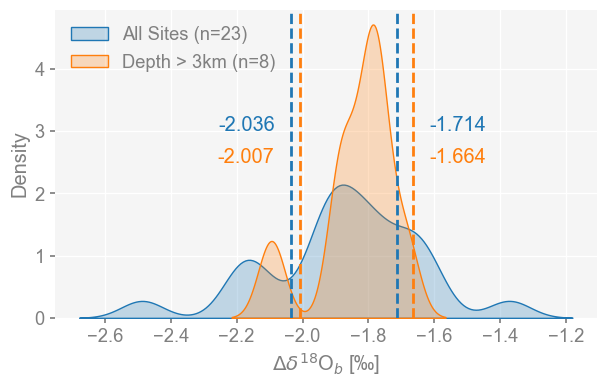

Figure saved at: "../figs/SIFig.05.pdf"


In [16]:
x4c.set_style('web', font_scale=1.2)
fig = plt.figure(figsize=(7, 4))
ax = sns.kdeplot(data=df_sites, x='anomaly', fill=True, label=f'All Sites (n={len(df_sites)})', bw_adjust=0.5, color='tab:blue')
ax.axvline(x=mu-sigma, color='tab:blue', linestyle='--')
ax.axvline(x=mu+sigma, color='tab:blue', linestyle='--')
ax.text(x=mu-sigma-0.22, y=3, s=f'{mu-sigma:.3f}', color='tab:blue')
ax.text(x=mu+sigma+0.1, y=3, s=f'{mu+sigma:.3f}', color='tab:blue')
sns.kdeplot(data=df_sites_deeper, x='anomaly', fill=True, label=f'Depth > 3km (n={len(df_sites_deeper)})', bw_adjust=0.5, ax=ax, color='tab:orange')
ax.axvline(x=mu_deeper-sigma_deeper, color='tab:orange', linestyle='--')
ax.axvline(x=mu_deeper+sigma_deeper, color='tab:orange', linestyle='--')
ax.text(x=mu_deeper-sigma_deeper-0.25, y=2.5, s=f'{mu_deeper-sigma_deeper:.3f}', color='tab:orange')
ax.text(x=mu_deeper+sigma_deeper+0.05, y=2.5, s=f'{mu_deeper+sigma_deeper:.3f}', color='tab:orange')
ax.set_xlabel(r'$\Delta \delta^{18}$O$_b$ [‰]')

ax.legend(loc='upper left')
x4c.showfig(fig)
x4c.savefig(fig, '../figs/SIFig.05.pdf')